In [ ]:
import numpy as np, matplotlib.pyplot as plt, scipy as sp
import matplotlib.image as mpimg
import torch
import time
import os, json
from datetime import datetime
import imageio.v3 as iio
from IPython.display import Image, display
from PIL import Image as PILImage



hbar = sp.constants.hbar
pi = sp.constants.pi

if torch.cuda.is_available():
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not found. Check your runtime settings.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define simulation parameters

class GPE:

    def __init__(self, Np, m, omega, a0, a02, gamma, sigma, N, ev_time,
                 time_steps, cutoff, cutoff_coeff = 1/3, waist=False,
                 high_precision=False, z_scale = 1, y_scale=1,
                 time_plots = True, final_plots = True, plot_steps = 0.1, Nz = None):

        self.debug = False
        self.time_plots = time_plots
        self.final_plots = final_plots
        self.plot_steps = plot_steps

        if not (self.plot_steps * time_steps).is_integer():
          print("Plot Step is not multiple of time steps. Choose plot step such that plot_step % of time_step = whole number.")

        if not int(1/self.plot_steps).is_integer():
          print("Choose plot step such that 1/plot_step is integer.")



        if high_precision:
            self.complex_type = torch.complex128
            self.real_type = torch.float64

        else:
            self.complex_type = torch.complex64
            self.real_type = torch.float32


        self.Np = Np
        self.m = m  #kg
        self.omega = omega #Hz
        self.a0 = a0 #m
        self.g0 = 4*pi*hbar**2*a0* Np/m
        self.gamma = gamma
        self.a02 = a02
        self.g2 = 6*np.sqrt(5) * pi * hbar**2 * a02 * Np / m
        self.sigma = sigma
        self.z_scale = z_scale
        self.y_scale = y_scale



        self.l = np.sqrt(hbar/(m * omega)) #length scale
        self.tau = 1/omega # time scale
        self.G0 = self.g0/(self.l**3*hbar*omega)
        self.G2 = self.g2/(hbar*omega*self.l**5)

        self.waist = waist
        self.cutoff = cutoff

        self.up = 5 * sigma
        self.N = N
        self.Nz = Nz

        self.ev_time = ev_time #s
        self.time_steps = time_steps
        self.dt = ev_time/time_steps
        self.dtau = self.dt/self.tau
        self.imag_dtau = 5e-3
        self.times = np.linspace(0, ev_time, time_steps)

        self.x = torch.linspace(-self.up,self.up,self.N+1, device=device, dtype=self.real_type)[:-1]
        self.dx = (self.x[1]-self.x[0]).item(); self.dxu = self.dx/self.l
        self.z = torch.linspace(-self.up, self.up, self.Nz+1, device=device, dtype = self.real_type)[:-1]
        self.dz = (self.z[1]-self.z[0]).item(); self.dzu = self.dz/self.l

        self.X, self.Y, self.Z = torch.meshgrid(self.x,self.x,self.z, indexing='ij')
        self.uX,self.uY, self.uZ = self.X/self.l, self.Y/self.l, self.Z/self.l

        k = 2*pi*torch.fft.fftfreq(self.N, d=self.dx/self.l, device=device, dtype=self.real_type)
        kz = 2*pi*torch.fft.fftfreq(self.Nz, d=self.dz/self.l, device=device, dtype = self.real_type)
        self.KX, self.KY, self.KZ = torch.meshgrid(k,k,kz, indexing="ij")  # Note that spacing d, is adjusted to represent spacing in uX/Y/Z
        self.cutoff_coeff = cutoff_coeff
        self.k_cutoff = pi/self.dx * (self.cutoff_coeff) #m^-1

        if a02 == 0:
            self.elastic_term = False

        else: self.elastic_term = True


        self.init_wf = self.gaussian().to(device)
        self.n0 = torch.max(torch.abs(self.init_wf)**2).item() * self.Np
        self.healing_length = 1/np.sqrt(8*pi*self.n0*a0)


        self.parameters = {
            "Np": self.Np,
            "m": self.m,
            "omega": self.omega,
            "a0": self.a0,
            "g0": self.g0,
            "gamma": self.gamma,
            "a02": self.a02,
            "g2": self.g2,
            "sigma": self.sigma,
            "Box Length": self.up*2,
            "Gaussian Z-Scale: ": self.z_scale,
            "Gaussian Y-Scale: ": self.y_scale,
            "N": self.N,
            "ev_time": self.ev_time,
            "time_steps": self.time_steps,
            "dt": self.dt,
            "dtau": self.dtau,
            "dx": self.dx,
            "dxu": self.dxu,
            "dz": self.dz,
            "dzu": self.dzu,
            "up": self.up,
            "healing_length": self.healing_length,
            "cutoff_coeff": self.cutoff_coeff,
            "cutoff": self.cutoff,
            "high_precision": high_precision,
            "G0": self.G0,
            "G2": self.G2,
            "l": self.l,
            "tau": self.tau,
            "Peak Density": self.n0,
            "Gas Parameter": self.n0 * self.a0**3
        }

    def params(self):
        print("-- Simulation Parameters --")
        print("Number of particles:", self.Np)
        print("Mass (kg):", self.m)
        print("Trap frequency (Hz):", self.omega)
        print("Gamma: ", self.gamma)
        print("Scattering length a0 (m):", self.a0)
        print("Scattering length a02 (m^3):", self.a02)
        print("g2/g0:", self.g2/self.g0)
        print("Evolution time (s):", self.ev_time)
        print("Time steps: ", self.time_steps)
        print("dt: ", self.dt)
        print("dtau = dt/tau: ", self.dtau)
        print("Unitless Time (time/tau): ", self.ev_time/self.tau)
        print("Number of 1D grid points: ", self.N)
        print("dx:", self.dx)
        print("dz: ", self.dz)
        print("Healing length (m):", self.healing_length)
        print("dx/healing length:", self.dx/self.healing_length)
        print("dz/healing length:", self.dz/self.healing_length)
        print("up/healing length: ", self.up / self.healing_length)
        print("cutoff coeff:", self.cutoff_coeff)
        print("Cutoff Type: ", self.cutoff)
        print("K_Max: ", self.KX.max().item())
        print("Particle Density: ", self.n0)
        print("na0^3: ", self.n0 * self.a0**3)

    def norm(self, f):
        mag = torch.sum(torch.abs(f)**2) * self.dx**2 * self.dz
        return mag.item()

    def unitless_norm(self,f):
        mag = torch.sum(torch.abs(f)**2) * self.dxu**2 * self.dzu
        return mag.item()

    def gaussian(self):
        sigma = self.sigma
        x, y, z = self.X, self.Y, self.Z
        ys, zs = self.y_scale, self.z_scale
        gaussian = torch.exp(-1*(x**2+(ys * y)**2+(zs * z)**2)/(2*sigma**2)).to(self.complex_type) # Gaussian ansatz exp(r^2/2sigma^2)
        norm = self.norm(gaussian)
        gaussian *= (1/norm)**(1/2)
        return gaussian

    def soft_cutoff(self):

        kc = self.k_cutoff * self.l
        delta_k = 0.1 * kc  # Unitless smearing width

        kx, ky, kz = self.KX, self.KY, self.KZ

        K_mag = torch.sqrt(kx**2+ky**2+kz**2)

        #exponent = torch.clip((K_mag - kc)/delta_k, -700, 700)

        #sig = 1/(1+torch.exp(exponent))

        sig = torch.sigmoid(-(K_mag - kc)/delta_k)

        return sig

    def set_directory(self, name=""):

      self.timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

      self.base_output_dir = name + f"simulation_data_{self.timestamp}"
      os.makedirs(self.base_output_dir, exist_ok=True)

      subfolders = ["XY Density", "XY and Initial Density", "XZ Density", "X Slice", "Y Slice", "Z Slice"]
      self.folder_paths = {}

      for folder in subfolders:
          path = os.path.join(self.base_output_dir, folder)
          os.makedirs(path, exist_ok=True)
          self.folder_paths[folder] = path  # Stores paths for easy access later

      # 2. Save the parameters as a JSON file inside the run folder
      param_filepath = os.path.join(self.base_output_dir, "global_parameters.json")
      with open(param_filepath, "w") as json_file:
          json.dump(self.parameters, json_file, indent=4)


    def save_plots(self, wf):

      # , folder_name = "Breathing Mode Data"

      """run_dir = os.path.join(self.base_output_dir, folder_name)
      os.makedirs(run_dir, exist_ok=True)"""

      xy_density_path = self.folder_paths["XY Density"]
      xy_init_density_path = self.folder_paths["XY and Initial Density"]
      xz_density_path = self.folder_paths["XZ Density"]
      x_slice_path = self.folder_paths["X Slice"]
      y_slice_path = self.folder_paths["Y Slice"]
      z_slice_path = self.folder_paths["Z Slice"]

      x = self.x.cpu().numpy()
      z = self.z.cpu().numpy()
      pX1, pY = np.meshgrid(x, x, indexing='ij')
      pX2, pZ = np.meshgrid(x, z, indexing="ij")

      dx, dz, l = self.dx, self.dz, self.l

      init_psi = self.init_wf.cpu().numpy()
      initial_xy_density = np.sum(np.abs(init_psi)**2 * dz, axis=2)
      u_initial_xy_density = np.sum(np.abs(init_psi*l**(3/2))**2 * dz/l, axis=2)

      current_wf = wf.cpu().numpy()
      uxy_density = np.sum(np.abs(current_wf)**2 * dz/l, axis=2)
      uxz_density = np.sum(np.abs(current_wf)**2 * dx/l, axis=1)



      fig1, ax1 = plt.subplots()
      ax1.set_aspect('equal', 'box')
      im1 = ax1.pcolormesh(pX1/l, pY/l, uxy_density)
      ax1.set_title(f"XY Density at Time t = {self.t} ms")
      ax1.set_xlabel("Unitless Distance (X)")
      ax1.set_ylabel("Unitless Distance (Y)")
      fig1.colorbar(im1, ax=ax1, label="Normalized Density")
      ax1.grid(True, alpha=0.4)
      fig1.tight_layout()
      fig1.savefig(os.path.join(xy_density_path, f"XY_Density_{self.index}.png"), dpi=300)
      plt.close(fig1) # Free memory


      ### Next Plot

      fig2, (ax2, ax3) = plt.subplots(2, 1, figsize=(8, 8), sharex=True) #, ax3, ax4, ax5
      ax2.set_aspect('equal', 'box')
      ax3.set_aspect('equal', 'box')

      scale_max = max(np.max(u_initial_xy_density),np.max(uxy_density))

      im2 = ax2.pcolormesh(pX1/l, pY/l, uxy_density, vmin=0, vmax=scale_max)
      ax2.set_title(f"XY Density at Time t = {self.t} ms")
      fig2.colorbar(im2, ax=ax2, label="Density")
      ax2.grid(True, alpha=0.4)

      im3 = ax3.pcolormesh(pX1/l, pY/l, u_initial_xy_density, vmin=0, vmax=scale_max)
      ax3.set_title("Initial XY Density")
      fig2.colorbar(im3, ax=ax3, label="Density")
      ax3.grid(True, alpha=0.4)

      fig2.tight_layout()
      fig2.savefig(os.path.join(xy_init_density_path, f"Initial_and_Evolved_XY_Density_{self.index}.png"), dpi=300)
      plt.close(fig2)

      ### Next Plot

      fig5, ax5 = plt.subplots()
      ax5.set_aspect('equal', 'box')
      im5 = ax5.pcolormesh(pX2/l, pZ/l, uxz_density)
      ax5.set_title(f"XZDensity t = {self.t} ms")
      ax5.set_xlabel("Unitless Distance (X)")
      ax5.set_ylabel("Unitless Distance (Z)")
      fig5.colorbar(im5, ax=ax5, label="Normalized Density")
      ax5.grid(True, alpha=0.4)
      fig5.tight_layout()
      fig5.savefig(os.path.join(xz_density_path, f"XZ_Density_{self.index}.png"), dpi=300)
      plt.close(fig5)

      ## Next plot

      fig6, ax6 = plt.subplots()
      ax6.set_aspect('equal', 'box')
      x_mid = current_wf.shape[0] // 2
      im6 = ax6.pcolormesh(pX2/l, pZ/l, np.abs(current_wf[x_mid,:,:])**2)
      ax6.set_title(f"Density Slice at x=0 at Time t = {self.t} ms")
      ax6.set_xlabel("Unitless Distance (Y)")
      ax6.set_ylabel("Unitless Distance (Z)")
      fig6.colorbar(im6, ax=ax6, label = "Normalized Density")
      ax6.grid(True, alpha=0.4)
      fig6.tight_layout()
      fig6.savefig(os.path.join(x_slice_path, f"DensitySliceX_{self.index}.png"), dpi=300)
      plt.close(fig6)

      ## Next Plot

      fig7, ax7 = plt.subplots()
      ax7.set_aspect('equal', 'box')
      y_mid = current_wf.shape[1] // 2
      im7 = ax7.pcolormesh(pX2/l, pZ/l, np.abs(current_wf[:,y_mid,:])**2)
      ax7.set_title(f"Density Slice at y=0 at Time t = {self.t} ms")
      ax7.set_xlabel("Unitless Distance (X)")
      ax7.set_ylabel("Unitless Distance (Z)")
      fig7.colorbar(im7, ax=ax7, label = "Normalized Density")
      ax7.grid(True, alpha=0.4)
      fig7.tight_layout()

      fig7.savefig(os.path.join(y_slice_path, f"DensitySliceY_{self.index}.png"), dpi=300)
      plt.close(fig7)

      ### Next Plot

      fig4, ax4 = plt.subplots()
      ax4.set_aspect('equal', 'box')
      z_mid = current_wf.shape[2] // 2
      im4 = ax4.pcolormesh(pX1/l, pY/l, np.abs(current_wf[:,:,z_mid])**2)
      ax4.set_title(f"Density Slice at z=0 at Time t = {self.t} ms")
      ax4.set_xlabel("Unitless Distance (X)")
      ax4.set_ylabel("Unitless Distance (Y)")
      fig4.colorbar(im4, ax=ax4, label="Normalized Density")
      ax4.grid(True, alpha=0.4)
      fig4.tight_layout()

      fig4.savefig(os.path.join(z_slice_path, f"DensitySliceZ_{self.index}.png"), dpi=300)
      plt.close(fig4)


    def save_final_plots(self):

      os.makedirs(self.base_output_dir, exist_ok=True) # Just in case, make data folder

      final_plots_filepath = os.path.join(self.base_output_dir, "Summary Plots") # Make path for folder for following plots
      self.folder_paths["Summary Plots"] = final_plots_filepath
      os.makedirs(final_plots_filepath, exist_ok=True) # Make folder

      # Energy contribution plot
      fig, ax = plt.subplots()

      times = [i for i in range(np.shape(self.energies)[0])] if self.imag else self.times

      ax.plot(times, self.energies)
      ax.set_xlabel("Time (s)")
      ax.set_ylabel("Energy (Unitless)")
      ax.set_title("Energy Contributions vs Time")
      ax.legend(["Kinetic Energy", "Potential", "g0 Term", "g2 Term", "Total"])
      fig.text(0.5, 0.01, f"Note: dt/tau = {self.dt/self.tau}. Only if this small will total energy be conserved.",
            ha="center", fontsize=10, wrap=True)

      ax.grid(True, alpha=0.4)

          # Adjust padding so the caption is not cut off
      fig.tight_layout()
      fig.subplots_adjust(bottom=0.15)


      fig.savefig(os.path.join(final_plots_filepath, "Energy Contributions.png"), dpi=300)
      plt.close(fig)

      # Waist plot

      if self.waist:

        plt.plot(self.times, self.waist_array)
        plt.xlabel("Time (s)")
        plt.ylabel("Waist (m)")
        plt.title("BEC Waist vs. Time")
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.savefig(os.path.join(final_plots_filepath, "Waist vs Time.png"), dpi=300)
        plt.close()


      # Initial Density Plot

      init_psi = self.init_wf.cpu().numpy()
      initial_xy_density = np.sum(np.abs(init_psi)**2 * self.dz, axis=2)
      u_initial_xy_density = np.sum(np.abs(init_psi*self.l**(3/2))**2 * self.dz/self.l, axis=2)

      initial_xz_density = np.sum(np.abs(init_psi)**2 * self.dx, axis=1)
      u_initial_xz_density = np.sum(np.abs(init_psi*self.l**(3/2))**2 * self.dx/self.l, axis=1)

      initial_yz_density = np.sum(np.abs(init_psi)**2 * self.dx, axis=0)
      u_initial_yz_density = np.sum(np.abs(init_psi*self.l**(3/2))**2 * self.dx/self.l, axis=0)

      x = self.x.cpu().numpy()
      z = self.z.cpu().numpy()
      pX, pY = np.meshgrid(x, x, indexing='ij')

      fig1, ax1 = plt.subplots()
      ax1.set_aspect('equal', 'box')
      im1 = ax1.pcolormesh(pX/self.l, pY/self.l, u_initial_xy_density)
      ax1.set_title("Initial XY Density")
      ax1.set_xlabel("Unitless Distance (X)")
      ax1.set_ylabel("Unitless Distance (Y)")
      fig1.colorbar(im1, ax=ax1, label="Normalized Density")
      ax1.grid(True, alpha=0.4)
      fig1.tight_layout()
      fig1.savefig(os.path.join(final_plots_filepath,"Initial XY Density.png"), dpi=300)
      plt.close(fig1)

      pX, pZ = np.meshgrid(x, z, indexing='ij')

      fig1, ax1 = plt.subplots()
      ax1.set_aspect('equal', 'box')
      im1 = ax1.pcolormesh(pX/self.l, pZ/self.l, u_initial_xz_density)
      ax1.set_title("Initial XZ Density")
      ax1.set_xlabel("Unitless Distance (X)")
      ax1.set_ylabel("Unitless Distance (Z)")
      fig1.colorbar(im1, ax=ax1, label="Normalized Density")
      ax1.grid(True, alpha=0.4)
      fig1.tight_layout()
      fig1.savefig(os.path.join(final_plots_filepath,"Initial XZ Density.png"), dpi=300)
      plt.close(fig1)

      fig1, ax1 = plt.subplots()
      ax1.set_aspect('equal', 'box')
      im1 = ax1.pcolormesh(pX/self.l, pZ/self.l, u_initial_yz_density)
      ax1.set_title("Initial YZ Density")
      ax1.set_xlabel("Unitless Distance (Y)")
      ax1.set_ylabel("Unitless Distance (Z)")
      fig1.colorbar(im1, ax=ax1, label="Normalized Density")
      ax1.grid(True, alpha=0.4)
      fig1.tight_layout()
      fig1.savefig(os.path.join(final_plots_filepath,"Initial YZ Density.png"), dpi=300)
      plt.close(fig1)

    def show_plots(self, plot_type: str, gif=True):
        #Plot_types = "XY" "Init and XY/XZ/YZ" "XZ" "XSlice" "YSlice" "ZSlice" "Init" "Energy" "Waist"

        if plot_type in ["XY", "Init and XY", "XZ", "XSlice", "YSlice", "ZSlice"]:

            if plot_type == "XY":
              image_folder = self.folder_paths["XY Density"]
              name = "XY_Density"

            elif plot_type == "Init and XY":
              image_folder = self.folder_paths["XY and Initial Density"]
              name = "XY_and_Initial_Density"

            elif plot_type == "XZ":
              image_folder = self.folder_paths["XZ Density"]
              name = "XZ_Density"

            elif plot_type == "XSlice":
              image_folder = self.folder_paths["X Slice"]
              name = "X_Slice"

            elif plot_type == "YSlice":
              image_folder = self.folder_paths["Y Slice"]
              name = "Y_Slice"

            elif plot_type == "ZSlice":
              image_folder = self.folder_paths["Z Slice"]
              name = "Z_Slice"

            plot_names = os.listdir(image_folder)
            ordered_plots = []

            for plot in plot_names:

                if plot[-3:] != "png":
                  continue

                index = plot[::-1].index("_")
                corrected_index = len(plot) - index - 1
                num = plot[corrected_index+1:-4]

                if num == "":
                  print("Issue with file name: ", plot)
                  print("Quitting show_plots().")
                  return

                ordered_plots.append((int(num), plot))

            ordered_plots = sorted(ordered_plots, key=lambda x:x[0])


            if gif:

                output_gif = os.path.join(image_folder, name + ".gif")

                frames = []

                for i in range(len(ordered_plots)):
                    plot_name = ordered_plots[i][1]

                    plot_path = os.path.join(image_folder, plot_name)

                    img = iio.imread(plot_path)

                    if i == 0:
                      target_shape = img.shape

                    if img.shape != target_shape:
                      target_size = (target_shape[1], target_shape[0])

                      # Convert numpy array to PIL Image, resize, and convert back
                      pil_img = PILImage.fromarray(img)
                      pil_img = pil_img.resize(target_size, Image.Resampling.LANCZOS)
                      pil_img_array = np.array(pil_img)

                    else:
                      pil_img_array = img

                    frames.append(pil_img_array)


                if frames:
                    # duration=200 means each snapshot stays on screen for 200 milliseconds (0.2 seconds)
                    iio.imwrite(output_gif, frames, duration=200, loop=0)
                    print(f"Success! Saved animation with {len(frames)} frames to {output_gif}")
                    display(Image(filename=output_gif))
                else:
                    print(f"Unable to retrieve {name} files.")


            else:

              # 1. Calculate how many snapshots we have
              num_plots = len(plot_names)

              # 2. Create a grid with 1 row and 'num_plots' columns
              # figsize=(20, 4) makes it wide horizontally so plots don't look squished
              fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(2 * num_plots, 8))
              plt.subplots_adjust(wspace=0.05, hspace=0.05)

              axes_flat = axes.flatten()

            # 3. Loop through your sequence and place each image in its own subplot
              for i in range(len(ordered_plots)):
                  # Construct the exact file path
                  plot_name = ordered_plots[i][1]
                  file_path = os.path.join(image_folder, plot_name)

                  # Read the image file
                  img = mpimg.imread(file_path)

                  # Display the image in the current subplot panel
                  axes_flat[i].imshow(img)

                  # Add a title to each individual panel to label the time
                  #axes_flat[i].set_title(f"t = {i}", fontsize=10)

                  # Hide the subplot axes lines so you only see your actual plot content
                  axes_flat[i].axis('off')

              # 4. Clean up the spacing so the plots sit neatly next to each other
              plt.tight_layout()
              plt.show()

        elif plot_type in ["Init XY", "Energy", "Waist"]:

          if plot_type == "Init XY":
            image_folder = self.folder_paths["Summary Plots"]
            name = "Initial XY Density.png"

          elif plot_type == "Init XZ":
            image_folder = self.folder_paths["Summary Plots"]
            name = "Initial XZ Density.png"

          elif plot_type == "Init YZ":
            image_folder = self.folder_paths["Summary Plots"]
            name = "Initial YZ Density.png"

          elif plot_type == "Energy":
            image_folder = self.folder_paths["Summary Plots"]
            name = "Energy Contributions.png"

          elif plot_type == "Waist":

            if not self.waist:
              print("Waist Data was not collected to produce a plot.")
              return

            image_folder = self.folder_paths["Summary Plots"]
            name = "Waist vs Time.png"

          img = mpimg.imread(os.path.join(image_folder, name))

          # figsize=(8, 6) gives a nice, standard large canvas for a single image
          fig, ax = plt.subplots(figsize=(8, 6))

          ax.imshow(img)
          ax.set_title(name[:-3])
          ax.axis('off') # Hides the blank axes lines

          fig.tight_layout()
          plt.show()

        else:

          print(f"Incorrectly specified plot type: f{plot_type} is not a valid plot type.")

    # Define operators

    def trap_potential(self):

        if self.imag == True:
            gam = 1

        elif self.imag == False:
            gam = self.gamma


        x,y,z = self.uX, self.uY, self.uZ
        return (1/2)*(x**2+y**2+gam**2*z**2) # Non-dimensionalized potential; Note that factor of i–it's built into the function

    def g0_term(self, psi): # in position basis
        return self.G0 * torch.abs(psi)**2


    def kinetic_energy(self):
        kx, ky, kz = self.KX, self.KY, self.KZ
        return (1/2) * (kx**2 + ky**2 + kz**2) # KE already in momentum space

    def quadrupole_term(self, psi):

        kx, ky, kz = self.KX, self.KY, self.KZ

        psi_mag_fft = torch.fft.fftn(torch.abs(psi)**2)
        op = psi_mag_fft * ((1/3)*(kx**2+ky**2+kz**2) - kz**2)

        if self.cutoff == "Hard Cutoff":

            k2 = kx**2+ky**2+kz**2
            unitless_k = (self.k_cutoff * self.l)**2

            mask = (k2 < (self.k_cutoff*self.l)**2)

            op *=mask

            op = self.G2 * torch.real(torch.fft.ifftn(op))

            return op

        elif self.cutoff == "Cylinder Cutoff":

            k2 = kx**2+ky**2+kz**2
            unitless_k = (self.k_cutoff * self.l)**2

            rho2 = kx**2+ky**2
            mask = (rho2 < unitless_k) & (kz**2 < unitless_k)

            op *=mask

            op = self.G2 * torch.real(torch.fft.ifftn(op))

            return op

        elif self.cutoff == "Soft Cutoff":

            sig = self.soft_cutoff()

            op *= sig

            op = self.G2 * torch.real(torch.fft.ifftn(op))

            return op


        elif self.cutoff == "No Cutoff":

            return self.G2 * torch.real(torch.fft.ifftn(op))

        elif self.cutoff == "Manual":

            rho_k2 = kx**2 + ky**2
            rho_cutoff = torch.max(rho_k2)
            mask_rho = (rho_k2 < (1/3)**2 * rho_cutoff)
            op *= mask_rho

            z_k2 = kz**2
            z_cutoff = torch.max(z_k2)
            mask_z = (z_k2 < (1/3)**2 * z_cutoff)
            op *= mask_z

            return self.G2 * torch.real(torch.fft.ifftn(op))

        else:
            raise ValueError("Invalid cutoff type. Choose from 'Hard Cutoff', 'Cylinder Cutoff', 'Soft Cutoff', or 'No Cutoff'.")


    @torch.compile
    def single_loop(self, wf, exp_potential_step, exp_KE_step):

        dtau = self.dtau

        if self.imag:
            dtau = self.imag_dtau
            dtau *= -1j

        wf *= exp_potential_step

        if self.elastic_term:
            q1 = self.quadrupole_term(wf)

        else: q1 = 0

        g0 = self.g0_term(wf)

        wf *= torch.exp(-1j *(g0 + q1) * (dtau/2))

        g2_energy = 0.5 * torch.sum(q1 * torch.abs(wf)**2).real * self.dxu**2 * self.dzu
        g0_energy = 0.5 * torch.sum(g0 * torch.abs(wf)**2).real * self.dxu**2 * self.dzu
        pot = torch.sum(self.potential_step * torch.abs(wf)**2).real * self.dxu**2 * self.dzu


        # Apply momentum-basis operators for interval dt

        wf = torch.fft.fftn(wf)

        wf *= exp_KE_step

        KE_energy = torch.sum(self.KE_step * torch.abs(wf)**2).real * self.dxu**2 * self.dzu/self.N**3

        wf = torch.fft.ifftn(wf)

        # Apply position-basis operators for interval dt/2

        wf *= exp_potential_step

        if self.elastic_term:
            q2 = self.quadrupole_term(wf)

        else: q2 = 0

        wf *= torch.exp(-1j*(self.g0_term(wf) + q2) * (dtau/2))

        self.energy = (KE_energy.item(), pot.item(), g0_energy.item(), g2_energy.item(), KE_energy.item() + pot.item() + g0_energy.item() + g2_energy.item())

        return wf


    def evolution(self, ground_state=False):

        self.ground_state = ground_state

        time_steps = self.time_steps
        self.imag = False

        dxu = self.dx/self.l
        dtau = self.dtau # unitless time step
        dt = self.dt


        self.params()



        uX, uY, uZ = self.uX, self.uY, self.uZ
        l = self.l


        wf = self.imag_evolution() if ground_state else self.init_wf

        if ground_state:
            self.init_wf = wf

        print("Psi initial normalization:", self.norm(wf))

        #Nondimensionalization
        wf = (wf * l**(3/2)).to(self.complex_type)

        self.potential_step = self.trap_potential()
        exp_potential = torch.exp(-1j *(self.potential_step) * (dtau/2))

        self.KE_step = self.kinetic_energy()
        KE_exp = torch.exp(-1j*(self.KE_step) * dtau)


        waist = []; uR2 = uX**2+uY**2+uZ**2

        og_start_time = time.perf_counter()
        start_time = time.perf_counter()

        print("Starting: 0% done")

        self.energy = ()
        self.energies = []

        self.set_directory("RealTimeEvolution")

        for i in range(time_steps):

            wf = self.single_loop(wf, exp_potential, KE_exp)

            self.energies.append(self.energy)

            if (i % (time_steps* self.plot_steps) == 0 and i > 0) or (i == time_steps-1):
                    print("Roughly {}% done".format(i/time_steps*100))
                    print("Elapsed time: {:.2f} minutes".format((time.perf_counter()-start_time)/60))
                    start_time = time.perf_counter()

                    self.t = str(np.round(i * dt*1000, decimals=1)).replace(".", "_")
                    self.index = str(i)
                    if self.time_plots: self.save_plots(wf)

            if self.waist: waist.append(torch.sum(torch.abs(wf)**2 * uR2)*dxu**3)

        print(f"Total time: {(time.perf_counter()-og_start_time)/60} min")

        waist = np.array(waist) * self.l**2
        self.waist_array = waist

        # Redimensionalize result

        redim_wf = wf* self.l**(-3/2)

        self.save_final_plots()

        self.redim_wf = redim_wf.cpu().numpy()
        wf = wf.cpu().numpy()

        print("Final WF normalization", self.norm(redim_wf))

        return wf


    def imag_evolution(self):

        dxu = self.dxu
        dtau = self.imag_dtau # unitless time step

        self.imag = True

        self.params()

        self.set_directory(name="ImaginaryTimeEvolution")

        uX, uY, uZ = self.uX, self.uY, self.uZ
        dx = self.dx
        l = self.l

        wf = self.init_wf

        print("Psi initial normalization:", self.norm(wf))

        #Nondimensionalization
        wf = (wf * l**(3/2)).to(self.complex_type)

        self.potential_step = self.trap_potential()
        exp_potential = torch.exp(-1 *(self.potential_step) * (dtau/2))

        self.KE_step = self.kinetic_energy()
        KE_exp = torch.exp(-1*(self.KE_step) * dtau)

        waist = []; uR2 = uX**2+uY**2+uZ**2

        og_start_time = time.perf_counter()
        start_time = time.perf_counter()

        print("Starting: 0% done")

        #self.energy = 0
        self.energies = []
        prev_energy = 1e10

        counter = 0; converge = False

        while not converge:

            wf = self.single_loop(wf, exp_potential, KE_exp)
            mag = self.unitless_norm(wf)
            wf *= (1/mag)**(1/2)

            self.energies.append(self.energy)
            total_energy = self.energy[-1]

            if counter % 25 == 0:
                    print("Elapsed time: {:.2f} minutes".format((time.perf_counter()-start_time)/60))
                    print(f"Energy: {total_energy}, change: {abs(total_energy-prev_energy)/abs(total_energy)}, step: {counter}, norm: {mag}")
                    #start_time = time.perf_counter()

                    self.t = str(np.round(counter * (self.imag_dtau) *1000, decimals=1)).replace(".", "_")
                    self.index = str(counter)
                    if self.time_plots: self.save_plots(wf)

            if abs(total_energy - prev_energy)/abs(total_energy) < 1e-6:
                converge = True
                break

            counter += 1; prev_energy = total_energy

            if self.waist: waist.append(np.sum(np.abs(wf)**2 * uR2)*dxu**3)

        print(f"Total time: {np.round((time.perf_counter()-og_start_time)/60,decimals=2)} min")

        waist = np.array(waist) * self.l**2
        self.waist_array = waist

        # Redimensionalize result


        redim_wf = wf* self.l**(-3/2)

        self.save_final_plots()

        self.imag = False


        if self.ground_state:
            return redim_wf

        self.redim_wf = redim_wf.cpu().numpy()
        wf = wf.cpu().numpy()

        print("Final WF normalization", self.norm(redim_wf))

        return wf


    def dprint(self, *args):
        if self.debug:
            print(*args)

GPU is available: Tesla T4


In [ ]:
sim = GPE(Np=1e5, m = 1.9e-25,
omega = 2 * pi * 40,
a0 = 2e-9,
gamma = 2,
a02 = 0,
sigma = 11e-6,
N=400,Nz = 400,
ev_time = 0.01, #s
time_steps = 10000,
cutoff="Hard Cutoff")
sim.evolution()

-- Simulation Parameters --
Number of particles: 100000.0
Mass (kg): 1.9e-25
Trap frequency (Hz): 251.32741228718345
Gamma:  2
Scattering length a0 (m): 2e-09
Scattering length a02 (m^3): 0
g2/g0: 0.0
Evolution time (s): 0.01
Time steps:  10000
dt:  1e-06
dtau = dt/tau:  0.0002513274122871834
Unitless Time (time/tau):  2.5132741228718345
Number of 1D grid points:  400
dx: 2.749984560068697e-07
dz:  2.749984560068697e-07
Healing length (m): 1.2142628121856156e-06
dx/healing length: 0.2264735881286568
dz/healing length: 0.2264735881286568
up/healing length:  45.29497193527865
cutoff coeff: 0.3333333333333333
Cutoff Type:  Hard Cutoff
K_Max:  16.89211654663086
Particle Density:  1.3492883030016e+19
na0^3:  1.0794306424012803e-07
Psi initial normalization: 1.0
Starting: 0% done


W0612 03:16:57.344000 1026 torch/_dynamo/variables/tensor.py:1379] [0/0] Graph break from `Tensor.item()`, consider setting:
W0612 03:16:57.344000 1026 torch/_dynamo/variables/tensor.py:1379] [0/0]     torch._dynamo.config.capture_scalar_outputs = True
W0612 03:16:57.344000 1026 torch/_dynamo/variables/tensor.py:1379] [0/0] or:
W0612 03:16:57.344000 1026 torch/_dynamo/variables/tensor.py:1379] [0/0]     env TORCHDYNAMO_CAPTURE_SCALAR_OUTPUTS=1
W0612 03:16:57.344000 1026 torch/_dynamo/variables/tensor.py:1379] [0/0] to include these operations in the captured graph.
W0612 03:16:57.344000 1026 torch/_dynamo/variables/tensor.py:1379] [0/0] 
W0612 03:16:57.344000 1026 torch/_dynamo/variables/tensor.py:1379] [0/0] Graph break: from user code at:
W0612 03:16:57.344000 1026 torch/_dynamo/variables/tensor.py:1379] [0/0]   File "/tmp/ipykernel_1026/3957563941.py", line 758, in single_loop
W0612 03:16:57.344000 1026 torch/_dynamo/variables/tensor.py:1379] [0/0]     self.energy = (KE_energy.item(

Roughly 10.0% done
Elapsed time: 3.04 minutes
Roughly 20.0% done
Elapsed time: 2.62 minutes
Roughly 30.0% done
Elapsed time: 2.62 minutes
Roughly 40.0% done
Elapsed time: 2.62 minutes
Roughly 50.0% done
Elapsed time: 2.62 minutes
Roughly 60.0% done
Elapsed time: 2.63 minutes
Roughly 70.0% done
Elapsed time: 2.63 minutes
Roughly 80.0% done
Elapsed time: 2.62 minutes
Roughly 90.0% done
Elapsed time: 2.62 minutes
Roughly 99.99% done
Elapsed time: 2.62 minutes
Total time: 26.73059298101667 min
Final WF normalization 1.0011138916015625


array([[[-8.94381547e-09+1.07875542e-09j,
         -4.52213067e-09-1.56496291e-08j,
          6.48087806e-10-3.76047193e-09j, ...,
          1.33021585e-08-7.46099404e-10j,
          1.43072736e-08-1.20073613e-08j,
          4.02364542e-09-1.75807529e-08j],
        [-1.01345676e-09+3.32225514e-09j,
         -2.65745342e-10-8.15518408e-09j,
          2.49031573e-09-1.09155718e-09j, ...,
          1.38416896e-08+9.32659194e-09j,
          7.92194488e-09-9.11368225e-09j,
         -8.75529260e-10-1.42655354e-08j],
        [-4.68976102e-09+1.05749862e-08j,
         -1.02546913e-08-1.40632848e-08j,
          9.54918722e-09-4.97248109e-09j, ...,
          5.58092816e-09-8.19608648e-09j,
          4.89485696e-09-7.34360184e-10j,
         -1.89731719e-09-1.80018711e-09j],
        ...,
        [-9.54052926e-09+2.23810814e-09j,
          1.23087709e-08-7.34071692e-09j,
          3.82819637e-10-1.01950870e-09j, ...,
          1.63462648e-08+1.43723620e-08j,
          5.66814506e-09-3.27497029e-09j

In [ ]:
sim.evolution()

-- Simulation Parameters --
Number of particles: 100000.0
Mass (kg): 1.9e-25
Trap frequency (Hz): 251.32741228718345
Gamma:  2
Scattering length a0 (m): 2e-09
Scattering length a02 (m^3): 6.666666666666667e-28
g2/g0: 1.1180339887498947e-18
Evolution time (s): 0.01
Time steps:  10000
dt:  1e-06
dtau = dt/tau:  0.0002513274122871834
Unitless Time (time/tau):  2.5132741228718345
Number of 1D grid points:  400
dx: 2.749984560068697e-07
Healing length (m): 1.2142628121856156e-06
dx/healing length: 0.2264735881286568
up/healing length:  45.29497193527865
cutoff coeff: 0.3333333333333333
Cutoff Type:  Hard Cutoff
K_Max:  16.89211654663086
Particle Density:  1.3492883030016e+19
na0^3:  1.0794306424012803e-07
Psi initial normalization: 1.0
Starting: 0% done
Roughly 10.0% done
Elapsed time: 5.42 minutes
Roughly 20.0% done
Elapsed time: 5.52 minutes
Roughly 30.0% done
Elapsed time: 5.50 minutes
Roughly 40.0% done
Elapsed time: 5.52 minutes
Roughly 50.0% done
Elapsed time: 5.53 minutes
Roughly 60.

array([[[-5.49994761e-09-3.33668337e-09j,
         -1.01642597e-08-1.69717538e-08j,
         -6.12295503e-09-1.18068382e-08j, ...,
          4.97348474e-09+6.47058229e-09j,
          4.66490846e-09+6.34465813e-10j,
          2.17196860e-09-5.46457990e-09j],
        [-1.47329560e-09-1.35927829e-08j,
         -6.96533098e-09-1.70238632e-08j,
         -1.95001926e-09-9.91668170e-09j, ...,
          4.46906512e-09+1.48837627e-08j,
          5.42568568e-09+9.71076375e-09j,
          1.06681126e-08-8.56137383e-09j],
        [-7.76931053e-09-8.79554829e-09j,
         -1.17126699e-08-4.98378361e-09j,
         -3.91288724e-10-8.59847571e-09j, ...,
          8.35209768e-09+1.71359082e-09j,
          4.60580463e-09+6.23687857e-09j,
          9.42668699e-09-7.53580220e-09j],
        ...,
        [ 3.76722875e-09+1.30446756e-08j,
          7.67998998e-09+5.23719068e-10j,
         -1.87879845e-09+2.20215224e-09j, ...,
         -7.77163045e-09+1.93406224e-09j,
         -1.40382204e-08+3.21890532e-08j

In [ ]:
sim.KX.max().item()/sim.l

np.float64(11366917.788125677)

Success! Saved animation with 10 frames to RealTimeEvolutionsimulation_data_20260612_031657/X Slice/X_Slice.gif


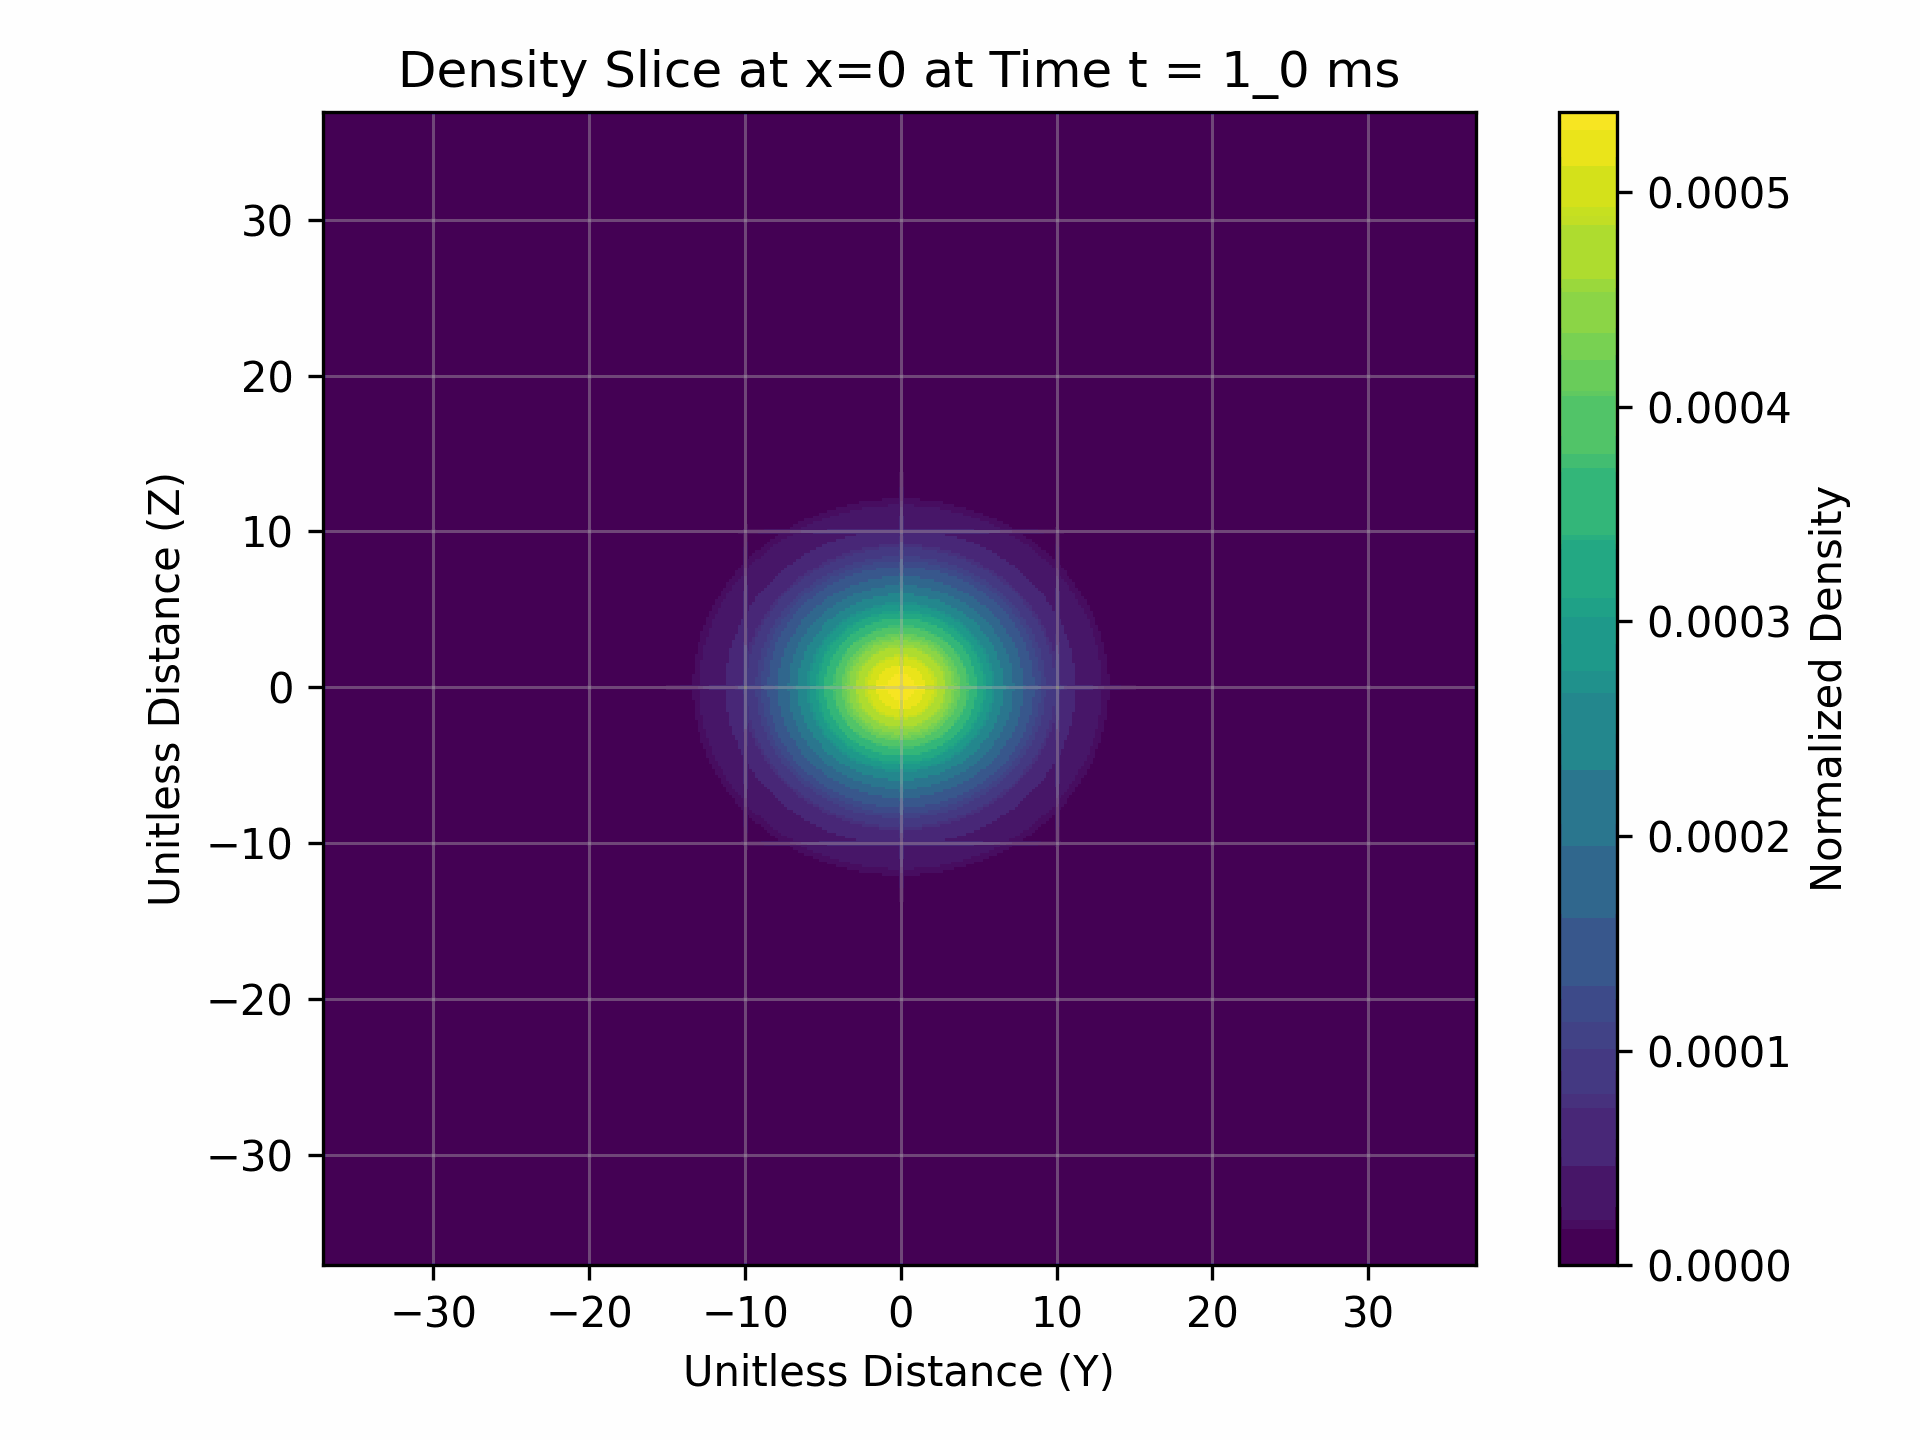

In [ ]:
sim.show_plots("XSlice")

In [ ]:
sim = GPE(Np=1e5, m = 1.9e-25,
omega = 2 * pi * 40,
a0 = 2e-9,
gamma = 5,
a02 = (2/3)*1e-27,
sigma = 11e-6,
N=400,
ev_time = 0.012*6, #s
time_steps = 12000,
cutoff_coeff = 1/3,
cutoff="Soft Cutoff")

init_psi = sim.init_wf.cpu().numpy()
initial_xy_density = np.sum(np.abs(init_psi)**2 * sim.dx, axis=2)
u_initial_xy_density = np.sum(np.abs(init_psi*sim.l**(3/2))**2 * sim.dx/sim.l, axis=1)

x = sim.x.cpu().numpy()
pX, pY = np.meshgrid(x, x, indexing='ij')



fig1, ax1 = plt.subplots()
im1 = ax1.pcolormesh(pX/sim.l, pY/sim.l, initial_xy_density)
ax1.set_title(f"t = 0")
ax1.set_xlabel("Unitless Distance (X)")
ax1.set_ylabel("Unitless Distance (Z)")
fig1.colorbar(im1, ax=ax1, label="Normalized Density")
ax1.grid(True, alpha=0.4)

fig1.savefig(f"Initial XZ Density.png", dpi=300, bbox_inches="tight")

KeyboardInterrupt: 

Success! Saved animation with 10 frames to RealTimeEvolutionsimulation_data_20260611_025226/Y Slice/Y_Slice.gif


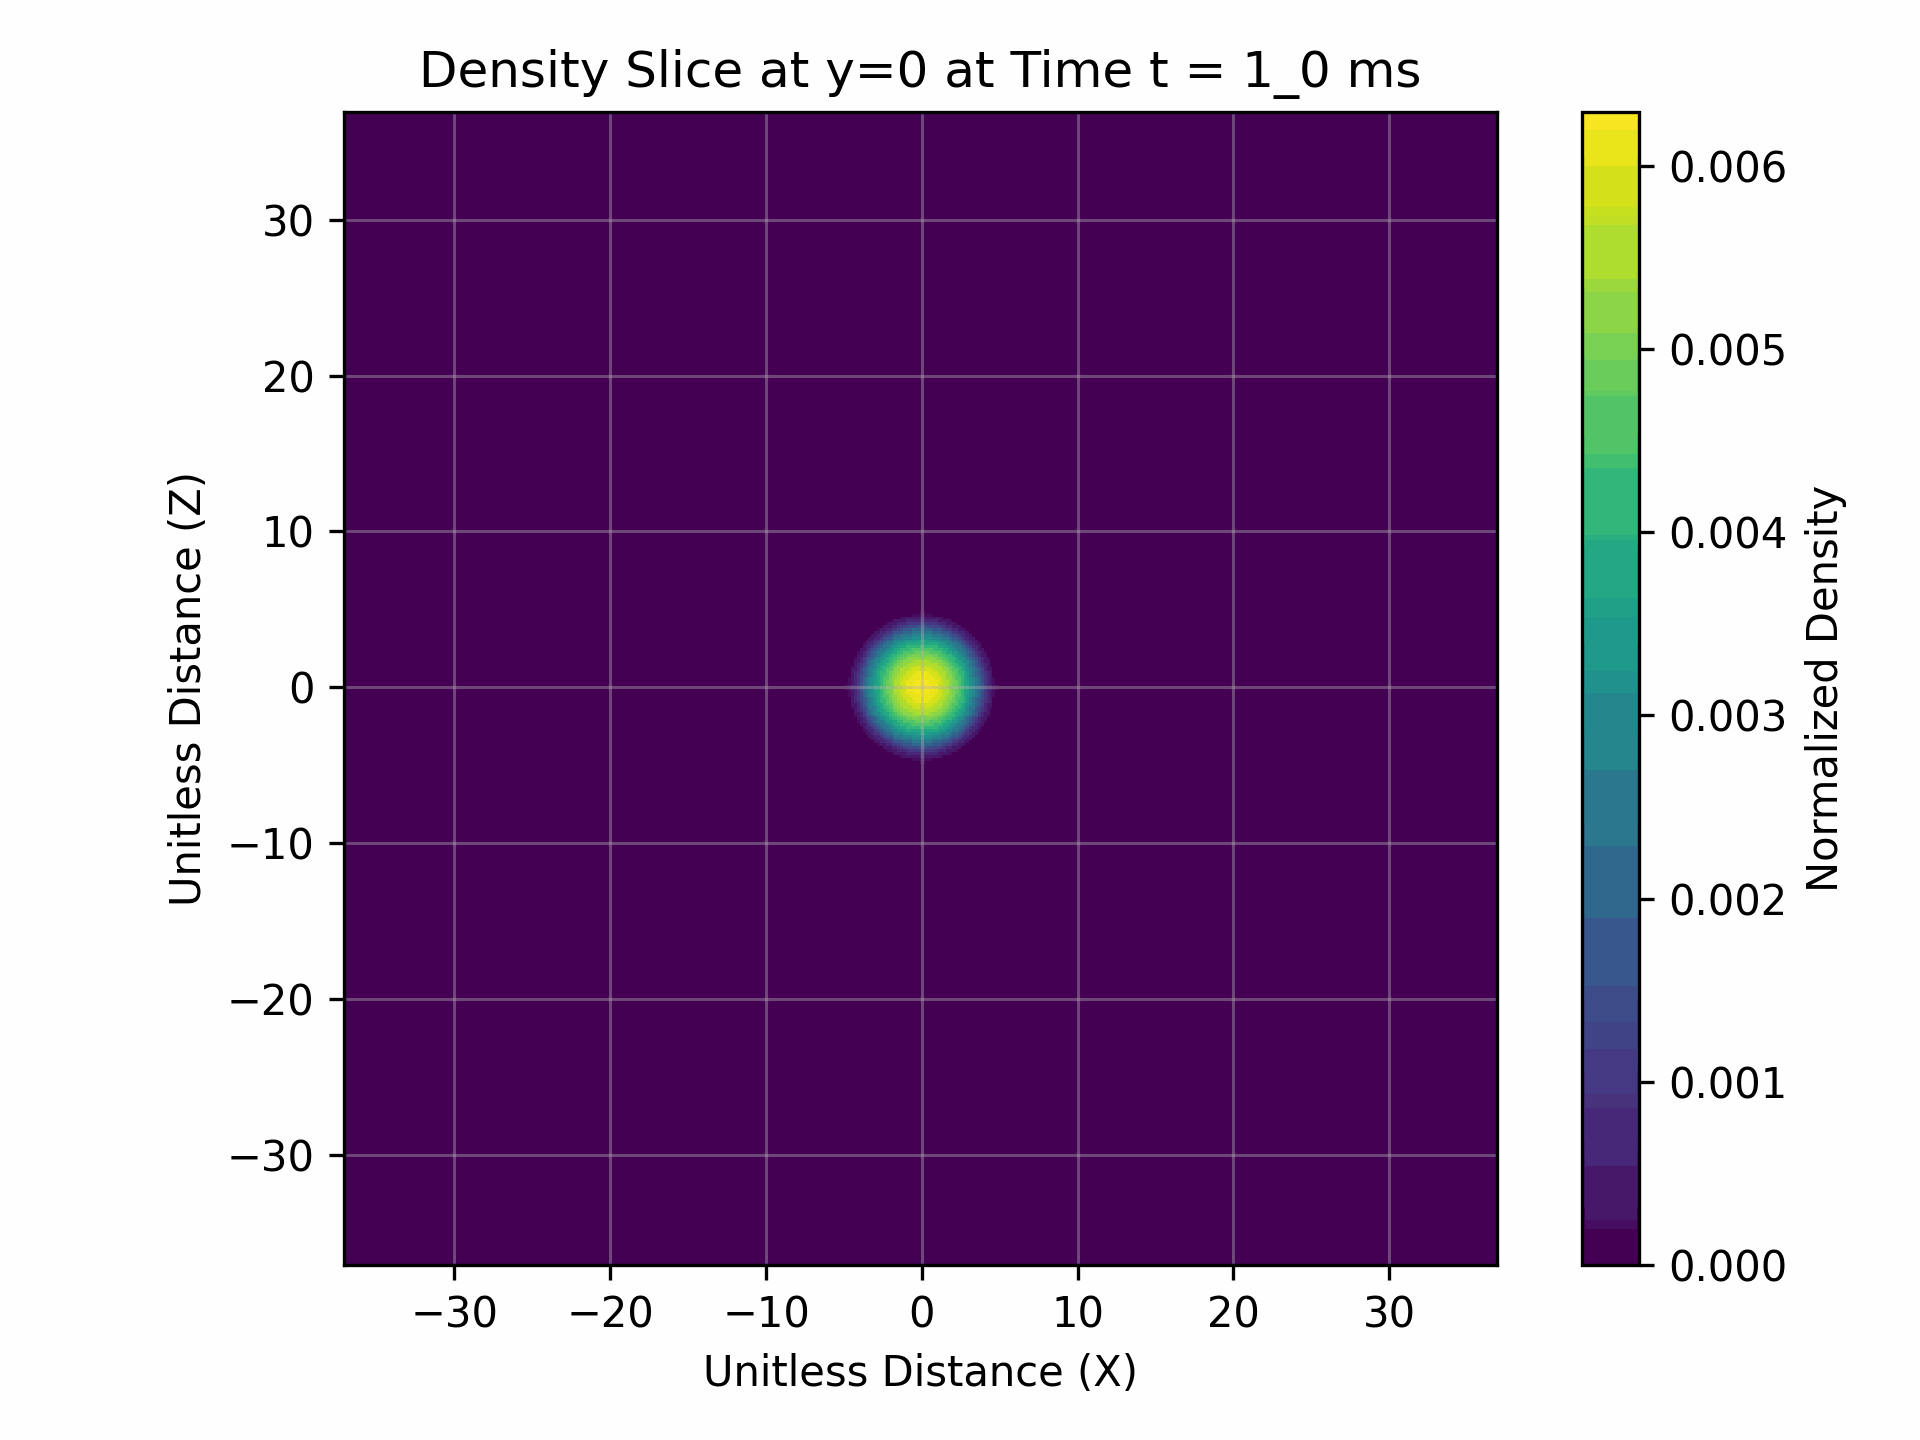

In [ ]:
sim.show_plots("YSlice")

In [ ]:
import shutil
from google.colab import files

# Replace 'my_folder' with the name of your folder
shutil.make_archive("NoG2TermZQuench", 'zip', "RealTimeEvolutionsimulation_data_20260612_031657")
files.download("NoG2TermZQuench.zip")

"""plt.figure()
plt.plot(pX[:, sim.N//2] / sim.l, xy_density[:, sim.N//2])
plt.title("1D Slice of Density")
plt.show()"""

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'plt.figure()\nplt.plot(pX[:, sim.N//2] / sim.l, xy_density[:, sim.N//2])\nplt.title("1D Slice of Density")\nplt.show()'